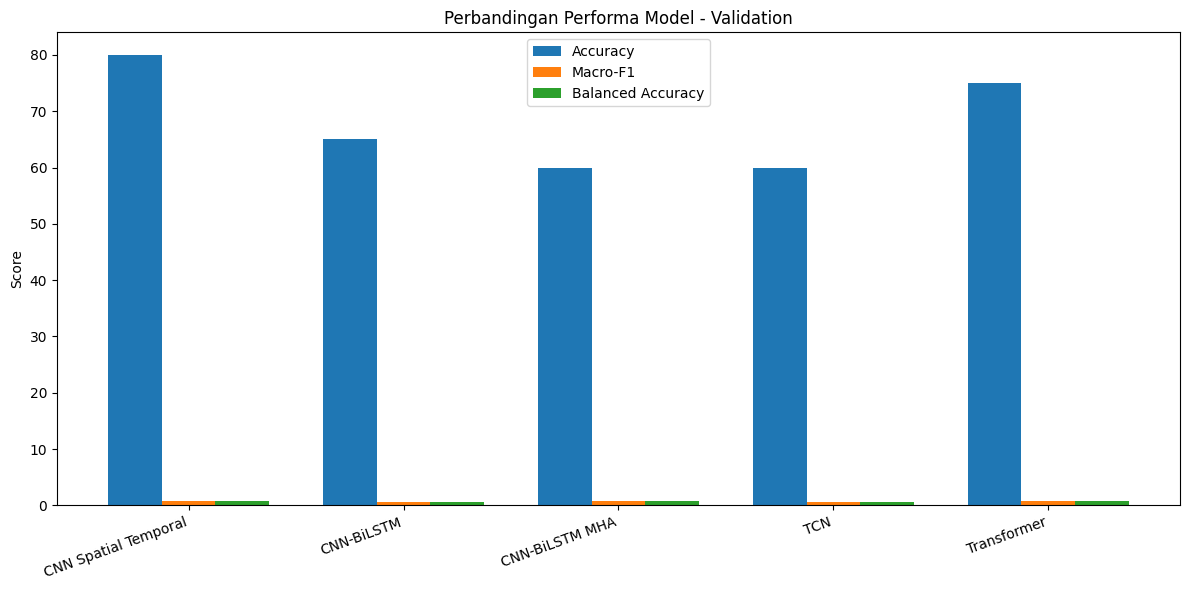

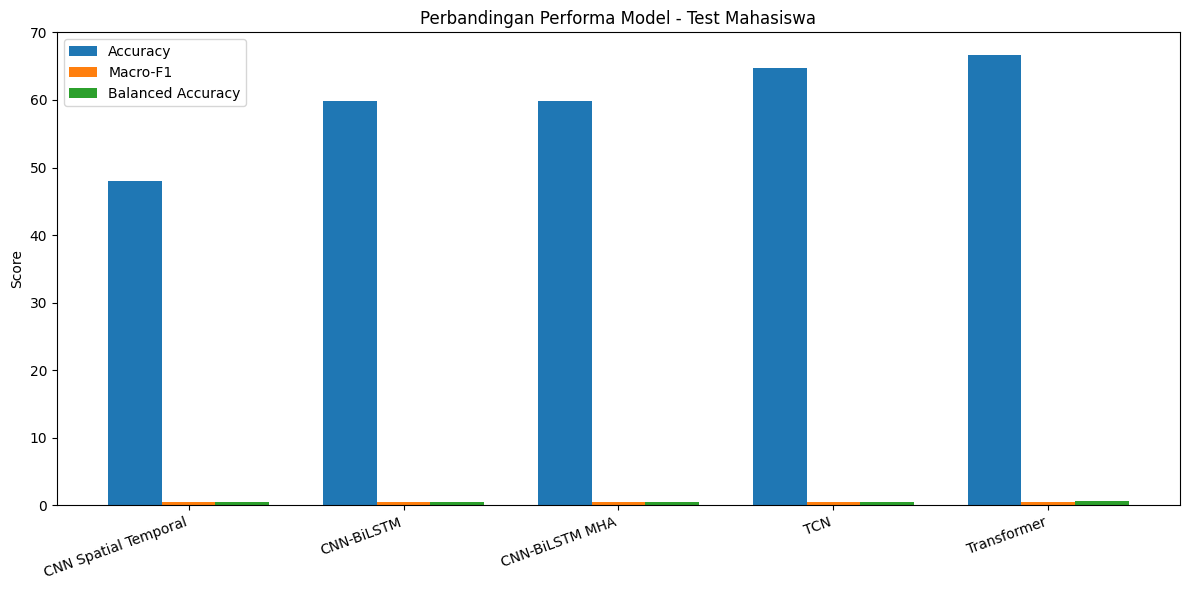

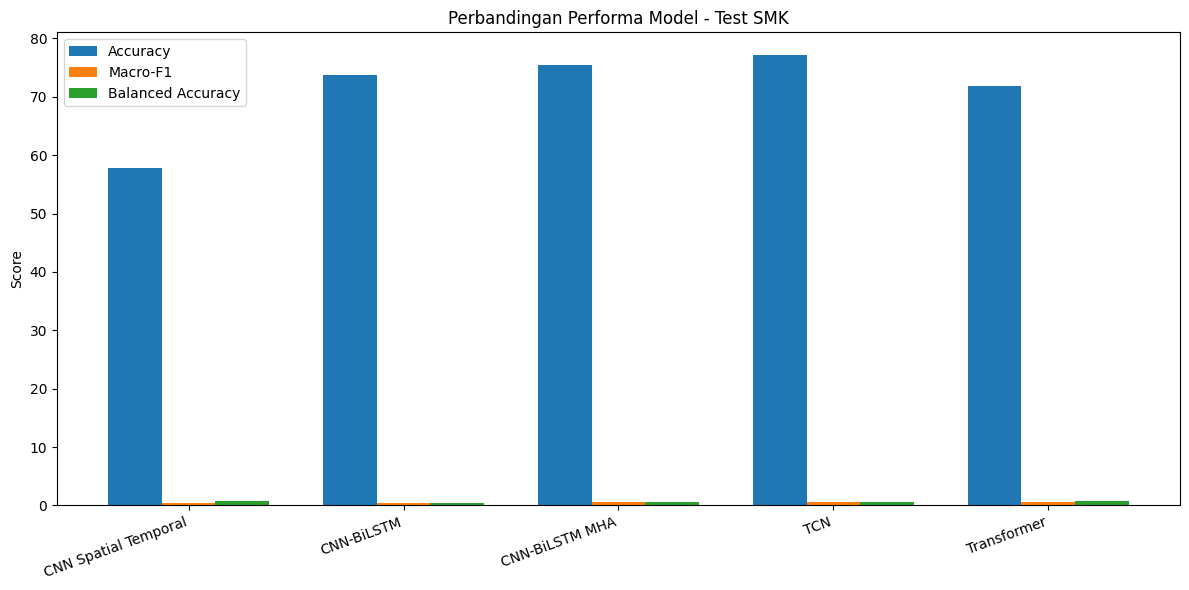

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data hasil eksperimen
data = [
    # Model, Dataset, Acc, MacroF1, BAcc
    ["CNN Spatial Temporal", "Validation", 80.00, 0.7980, 0.7980],
    ["CNN Spatial Temporal", "Test Mahasiswa", 48.04, 0.4655, 0.5163],
    ["CNN Spatial Temporal", "Test SMK", 57.89, 0.4971, 0.7692],

    ["CNN-BiLSTM", "Validation", 65.00, 0.6419, 0.6414],
    ["CNN-BiLSTM", "Test Mahasiswa", 59.80, 0.5112, 0.5133],
    ["CNN-BiLSTM", "Test SMK", 73.68, 0.4815, 0.4942],

    ["CNN-BiLSTM MHA", "Validation", 60.00, 0.7151, 0.7222],
    ["CNN-BiLSTM MHA", "Test Mahasiswa", 59.80, 0.5112, 0.5133],
    ["CNN-BiLSTM MHA", "Test SMK", 75.44, 0.5382, 0.5942],

    ["TCN", "Validation", 60.00, 0.6703, 0.6768],
    ["TCN", "Test Mahasiswa", 64.71, 0.5354, 0.5348],
    ["TCN", "Test SMK", 77.19, 0.5506, 0.6038],

    ["Transformer", "Validation", 75.00, 0.7442, 0.7424],
    ["Transformer", "Test Mahasiswa", 66.67, 0.5816, 0.5837],
    ["Transformer", "Test SMK", 71.93, 0.5494, 0.7775],
]

df = pd.DataFrame(
    data,
    columns=["Model", "Dataset", "Accuracy", "MacroF1", "BAcc"]
)

# Dataset yang akan divisualisasikan
datasets = ["Validation", "Test Mahasiswa", "Test SMK"]
metrics = ["Accuracy", "MacroF1", "BAcc"]

for dataset in datasets:
    subset = df[df["Dataset"] == dataset]

    x = np.arange(len(subset))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(x - width, subset["Accuracy"], width, label="Accuracy")
    ax.bar(x, subset["MacroF1"], width, label="Macro-F1")
    ax.bar(x + width, subset["BAcc"], width, label="Balanced Accuracy")

    ax.set_title(f"Perbandingan Performa Model - {dataset}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(subset["Model"], rotation=20, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.show()

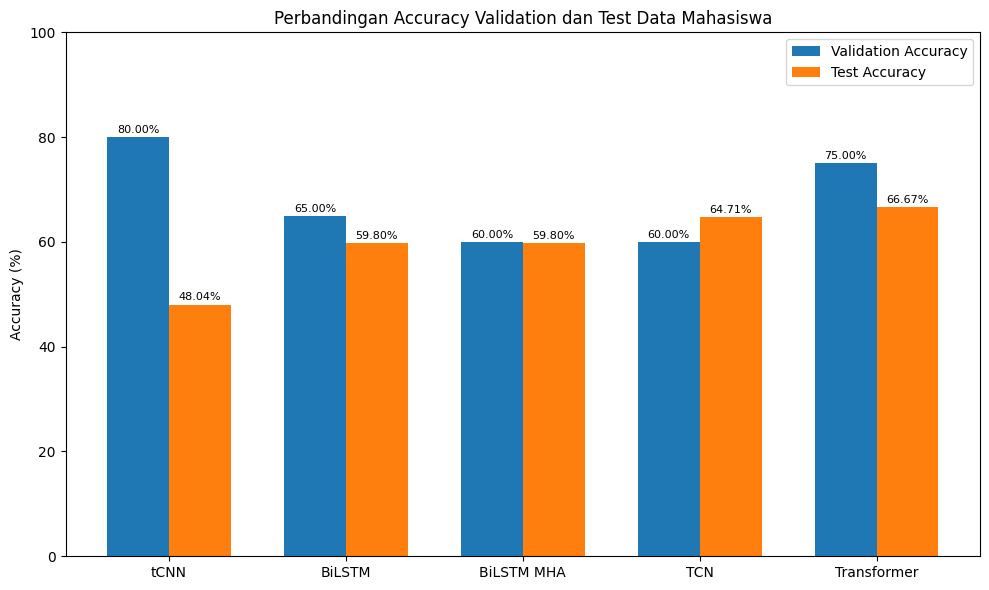

In [1]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "tCNN",
    "BiLSTM",
    "BiLSTM MHA",
    "TCN",
    "Transformer"
]

# Accuracy (%)
val_acc = [80.00, 65.00, 60.00, 60.00, 75.00]
test_acc = [48.04, 59.80, 59.80, 64.71, 66.67]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    val_acc,
    width,
    label="Validation Accuracy"
)

bars2 = ax.bar(
    x + width/2,
    test_acc,
    width,
    label="Test Accuracy"
)

ax.set_title(
    "Perbandingan Accuracy Validation dan Test Data Mahasiswa"
)
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 100)
ax.legend()

# Tampilkan nilai di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.2f}%',
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

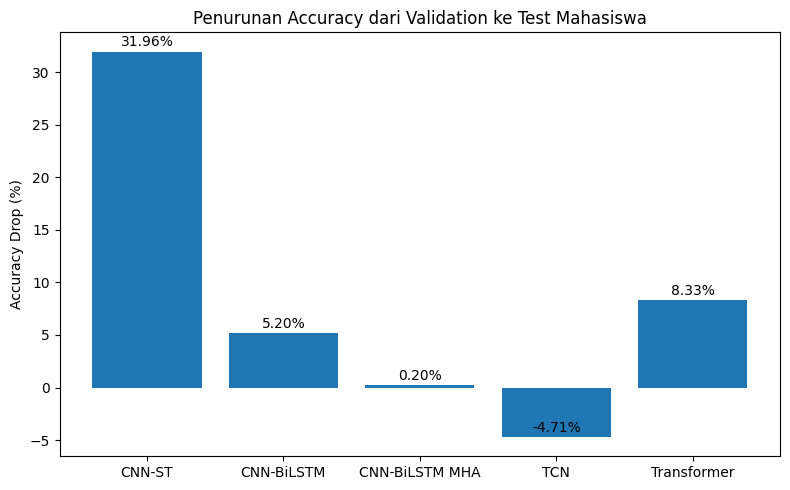

In [4]:
import matplotlib.pyplot as plt

models = [
    "CNN-ST",
    "CNN-BiLSTM",
    "CNN-BiLSTM MHA",
    "TCN",
    "Transformer"
]

val_acc = [80.00, 65.00, 60.00, 60.00, 75.00]
test_acc = [48.04, 59.80, 59.80, 64.71, 66.67]

drop_acc = [v - t for v, t in zip(val_acc, test_acc)]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, drop_acc)

plt.title("Penurunan Accuracy dari Validation ke Test Mahasiswa")
plt.ylabel("Accuracy Drop (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha='center'
    )

plt.tight_layout()
plt.show()